# PostgreSQL WAL Analysis

Анализ результатов работы `postgres_wal_monitor.py`

Источник данных: CSV файлы в `data/wal_history_*.csv`

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from pathlib import Path
from datetime import datetime
import os

## 1. Load Data

In [7]:
# Auto-find latest CSV file
DATA_DIR = Path(r"D:\py_pro\jira_focus_exporter\bz\Anomaly Detection\data")

wal_files = sorted(
    DATA_DIR.glob("wal_history_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True
)

if wal_files:
    csv_file = wal_files[0]
    print(f"Selected file: {csv_file.name}")
    
    # Load CSV
    df = pd.read_csv(csv_file, parse_dates=["timestamp"])
    print(f"Loaded {len(df)} records")
    print(f"\nFirst record: {df['timestamp'].min()}")
    print(f"Last record: {df['timestamp'].max()}")
else:
    print("No WAL history files found")
    df = pd.DataFrame()

Selected file: wal_history_20260723_192607.csv
Loaded 128 records

First record: 2026-07-23 19:26:07
Last record: 2026-07-23 20:29:40


In [8]:
# Preview data
if not df.empty:
    df.head(10)

## 2. Data Preparation

In [9]:
if not df.empty:
    # Normalize types from CSV
    df['wal_bytes'] = df['wal_bytes'].astype('int64')
    df['wal_records'] = df['wal_records'].astype('int64')
    
    # Calculate WAL GB from wal_bytes (primary source)
    df['wal_gb'] = df['wal_bytes'] / 1024**3
    
    # Calculate deltas
    df['wal_bytes_delta'] = df['wal_bytes'].diff()
    df['wal_records_delta'] = df['wal_records'].diff()
    
    # Calculate time delta in minutes
    df['time_delta_min'] = df['timestamp'].diff().dt.total_seconds() / 60
    
    # Calculate speeds
    df['wal_speed_mb_min'] = (df['wal_bytes_delta'] / 1024**2) / df['time_delta_min']
    df['records_per_min'] = df['wal_records_delta'] / df['time_delta_min']
    
    # Fill NaN for first row
    df['wal_bytes_delta'] = df['wal_bytes_delta'].fillna(0)
    df['wal_records_delta'] = df['wal_records_delta'].fillna(0)
    df['wal_speed_mb_min'] = df['wal_speed_mb_min'].fillna(0)
    df['records_per_min'] = df['records_per_min'].fillna(0)
    
    print("Data prepared")
    print(f"WAL range: {df['wal_gb'].min():.2f} - {df['wal_gb'].max():.2f} GB")
    print(f"Records range: {df['wal_records'].min():,} - {df['wal_records'].max():,}")

Data prepared
WAL range: 164.69 - 164.69 GB
Records range: 915,990,213 - 915,990,531


## 3. Summary

In [10]:
if not df.empty:
    duration = df['timestamp'].max() - df['timestamp'].min()
    hours = int(duration.total_seconds() // 3600)
    minutes = int((duration.total_seconds() % 3600) // 60)
    
    initial_wal = df['wal_gb'].iloc[0]
    current_wal = df['wal_gb'].iloc[-1]
    generated_wal = current_wal - initial_wal
    
    initial_records = df['wal_records'].iloc[0]
    current_records = df['wal_records'].iloc[-1]
    generated_records = current_records - initial_records
    
    avg_speed = df['wal_speed_mb_min'].mean()
    max_speed = df['wal_speed_mb_min'].max()
    avg_records = df['records_per_min'].mean()
    
    print("=" * 60)
    print("PostgreSQL WAL Analysis")
    print("=" * 60)
    print(f"\nFile: {csv_file.name}")
    print(f"\nMonitoring period:")
    print(f"  {df['timestamp'].min().strftime('%H:%M:%S')} - {df['timestamp'].max().strftime('%H:%M:%S')}")
    print(f"\nSamples: {len(df)}")
    print(f"Duration: {hours}h {minutes}m")
    print(f"\nInitial WAL: {initial_wal:.2f} GB")
    print(f"Final WAL: {current_wal:.2f} GB")
    print(f"Generated WAL: {generated_wal:.2f} GB")
    print(f"\nAverage WAL speed: {df['wal_speed_mb_min'].mean():.0f} MB/min")
    print(f"Max WAL speed: {df['wal_speed_mb_min'].max():.0f} MB/min")
    print(f"\nWAL records generated: {df['wal_records'].iloc[-1] - df['wal_records'].iloc[0]:,}")
    print(f"Average records/min: {df['records_per_min'].mean():,.0f}")
    print("=" * 60)

PostgreSQL WAL Analysis

File: wal_history_20260723_192607.csv

Monitoring period:
  19:26:07 - 20:29:40

Samples: 128
Duration: 1h 3m

Initial WAL: 164.69 GB
Final WAL: 164.69 GB
Generated WAL: 0.00 GB

Average WAL speed: 0 MB/min
Max WAL speed: 0 MB/min

WAL records generated: 318
Average records/min: 5


## 4. WAL Growth Chart

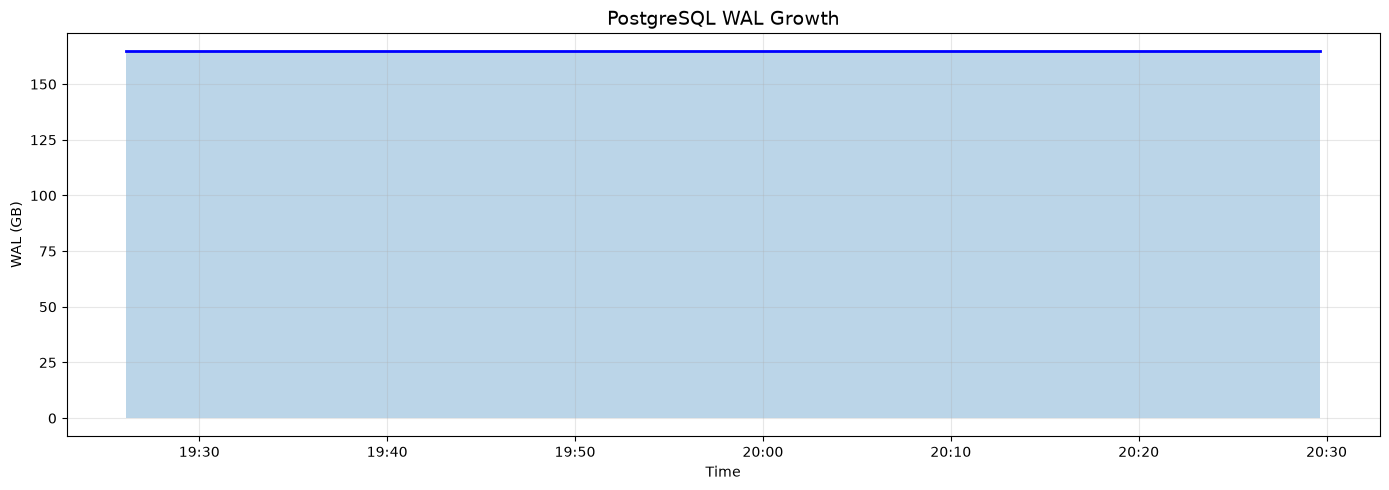

In [11]:
if not df.empty:
    plt.figure(figsize=(14, 5))
    plt.plot(df['timestamp'], df['wal_gb'], 'b-', linewidth=2)
    plt.fill_between(df['timestamp'], df['wal_gb'], alpha=0.3)
    plt.title('PostgreSQL WAL Growth', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('WAL (GB)')
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()

## 5. WAL Speed Chart

Average speed: 0 MB/min
Maximum: 0 MB/min
Current: 0 MB/min


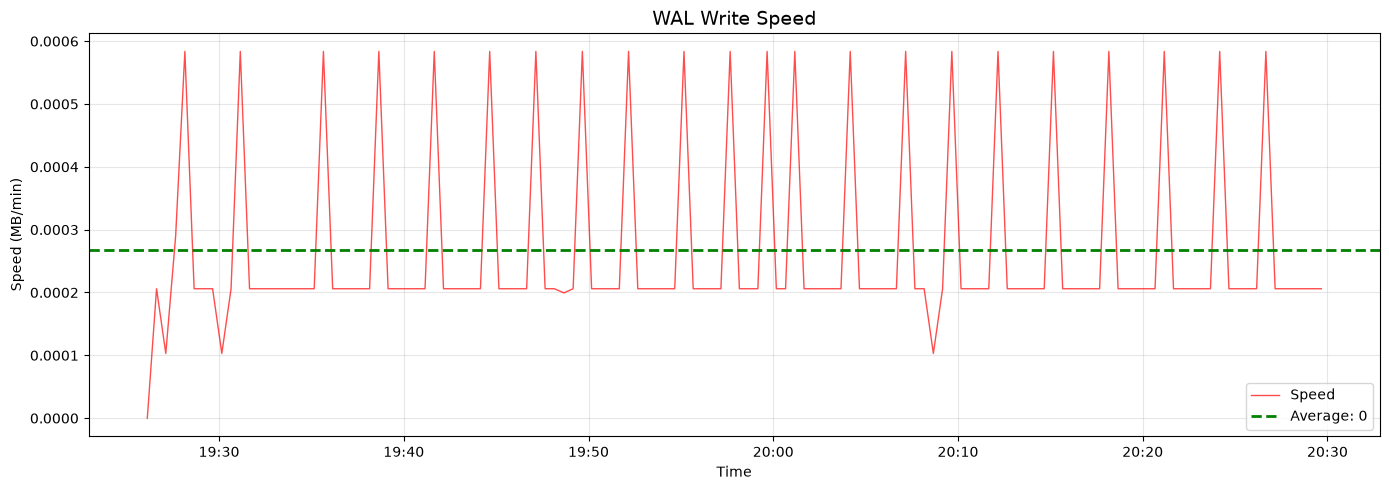

In [12]:
if not df.empty:
    avg_speed = df['wal_speed_mb_min'].mean()
    max_speed = df['wal_speed_mb_min'].max()
    current_speed = df['wal_speed_mb_min'].iloc[-1]
    
    print(f"Average speed: {avg_speed:.0f} MB/min")
    print(f"Maximum: {max_speed:.0f} MB/min")
    print(f"Current: {current_speed:.0f} MB/min")
    
    plt.figure(figsize=(14, 5))
    plt.plot(df['timestamp'], df['wal_speed_mb_min'], 'r-', linewidth=1, alpha=0.7, label='Speed')
    plt.axhline(y=avg_speed, color='g', linestyle='--', linewidth=2, label=f'Average: {avg_speed:.0f}')
    plt.title('WAL Write Speed', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('Speed (MB/min)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()

## 6. WAL Records Chart

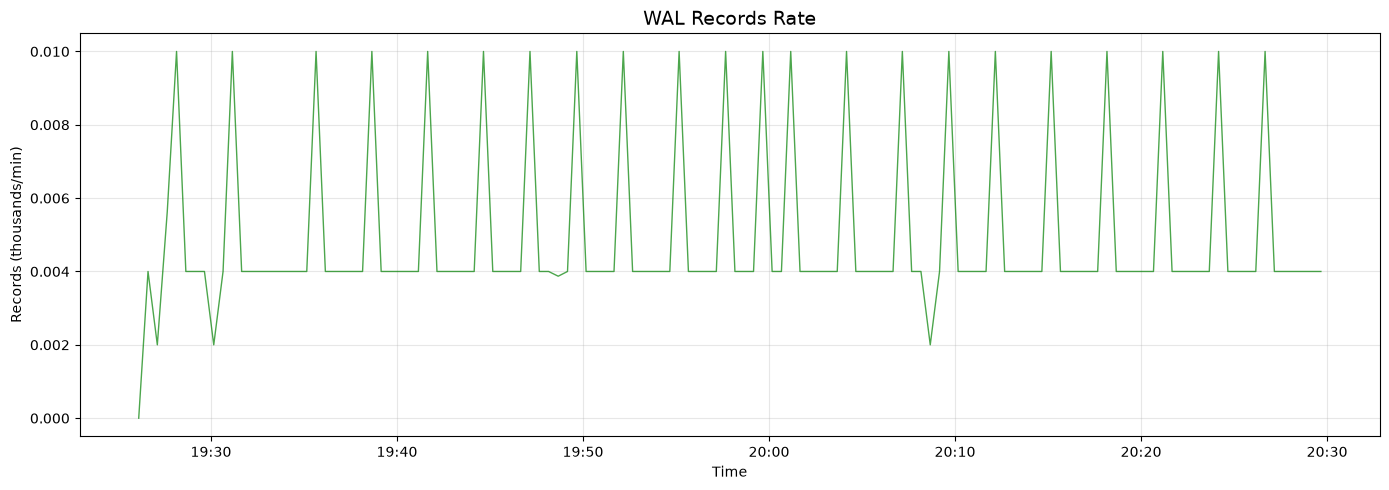

In [13]:
if not df.empty:
    plt.figure(figsize=(14, 5))
    plt.plot(df['timestamp'], df['records_per_min'] / 1000, 'g-', linewidth=1, alpha=0.7)
    plt.title('WAL Records Rate', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('Records (thousands/min)')
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()

## 7. Stability Analysis

In [14]:
if not df.empty:
    # Classification
    df['status'] = 'NORMAL'
    df.loc[df['wal_speed_mb_min'] < 50, 'status'] = 'SLOW'
    df.loc[df['wal_speed_mb_min'] == 0, 'status'] = 'IDLE'
    
    status_counts = df['status'].value_counts()
    
    total_minutes = len(df)
    slow_minutes = status_counts.get('SLOW', 0)
    idle_minutes = status_counts.get('IDLE', 0)
    normal_minutes = status_counts.get('NORMAL', 0)
    
    print("Performance status:")
    if slow_minutes > total_minutes * 0.3:
        print("  SLOW")
    elif idle_minutes > total_minutes * 0.1:
        print("  INTERMITTENT")
    else:
        print("  NORMAL")
    
    print(f"\nSlow periods: {slow_minutes} minutes ({slow_minutes/total_minutes*100:.1f}%)")
    print(f"Idle periods: {idle_minutes} minutes ({idle_minutes/total_minutes*100:.1f}%)")
    print(f"Normal periods: {normal_minutes} minutes ({normal_minutes/total_minutes*100:.1f}%)")

Performance status:
  SLOW

Slow periods: 127 minutes (99.2%)
Idle periods: 1 minutes (0.8%)
Normal periods: 0 minutes (0.0%)


## 8. Forecast

In [15]:
if not df.empty:
    avg_speed = df['wal_speed_mb_min'].mean()
    current_wal = df['wal_gb'].iloc[-1]
    
    hourly_wal = (avg_speed * 60) / 1024  # Convert to GB/hour
    
    print("Forecast:")
    print(f"  Current WAL: {current_wal:.2f} GB")
    print(f"  Average speed: {avg_speed:.0f} MB/min")
    print(f"  Estimated hourly WAL: {hourly_wal:.2f} GB/hour")
    
    # Time to specific target
    targets = [200, 250, 300]
    print(f"\nTime to reach target:")
    for target in targets:
        remaining_gb = target - current_wal
        if remaining_gb > 0 and avg_speed > 0:
            remaining_minutes = (remaining_gb * 1024) / avg_speed
            hours = int(remaining_minutes // 60)
            mins = int(remaining_minutes % 60)
            print(f"  {target} GB: {hours}h {mins}m")

Forecast:
  Current WAL: 164.69 GB
  Average speed: 0 MB/min
  Estimated hourly WAL: 0.00 GB/hour

Time to reach target:
  200 GB: 2253240h 26m
  250 GB: 5443490h 10m
  300 GB: 8633739h 54m


## 9. Activity Analysis

Activity data: 175 records


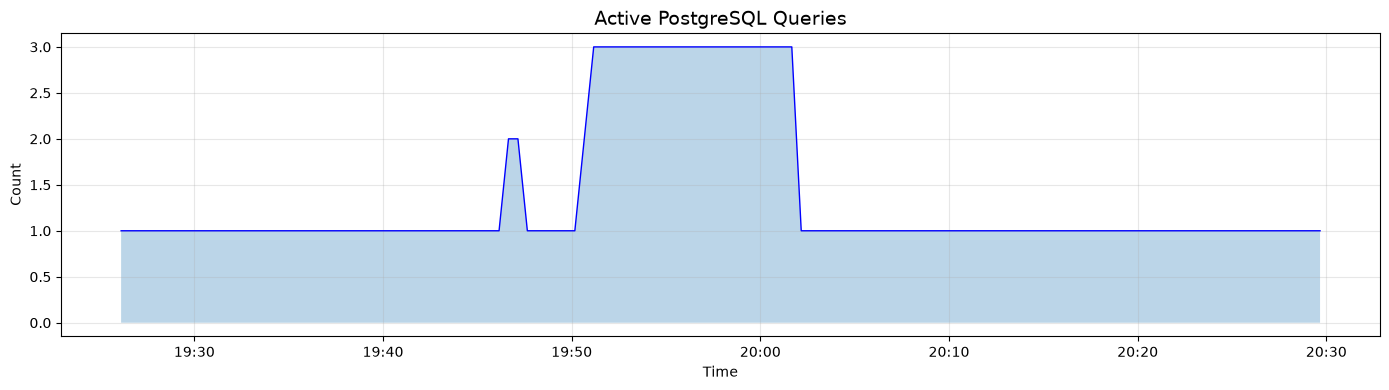

In [16]:
# Load activity data if available
activity_files = sorted(
    DATA_DIR.glob("activity_history_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True
)

if activity_files:
    activity_df = pd.read_csv(activity_files[0], parse_dates=["timestamp"])
    print(f"Activity data: {len(activity_df)} records")
    
    # Count active queries per timestamp
    activity_counts = activity_df.groupby('timestamp').size()
    
    plt.figure(figsize=(14, 4))
    plt.plot(activity_counts.index, activity_counts.values, 'b-', linewidth=1)
    plt.fill_between(activity_counts.index, activity_counts.values, alpha=0.3)
    plt.title('Active PostgreSQL Queries', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()
else:
    print("No activity history files found")

## 10. Bottleneck Analysis

In [17]:
if 'activity_df' in locals() and not activity_df.empty:
    # Wait events analysis
    wait_events = activity_df[activity_df['wait_event'].notna()]['wait_event'].value_counts()
    
    if not wait_events.empty:
        print("Wait Events Distribution:")
        for event, count in wait_events.head(5).items():
            print(f"  {event}: {count}")
        
        # Check for bottleneck
        top_event = wait_events.index[0]
        print(f"\nDetected bottleneck: {top_event}")
        
        recommendations = {
            'WALWriteLock': [
                'Reduce transaction size',
                'Use batch commit',
                'UPDATE in chunks'
            ],
            'Lock': [
                'Check for deadlocks',
                'Reduce lock duration'
            ],
            'IO': [
                'Check disk I/O',
                'Use faster storage'
            ],
            'DataFileRead': [
                'Increase shared_buffers',
                'Add indexes'
            ]
        }
        
        print("\nRecommendations:")
        for key, recs in recommendations.items():
            if key.lower() in top_event.lower():
                for rec in recs:
                    print(f"  - {rec}")
                break

Wait Events Distribution:
  DataFileRead: 119
  ClientRead: 47
  DataFileExtend: 1
  DataFileWrite: 1

Detected bottleneck: DataFileRead

Recommendations:
  - Increase shared_buffers
  - Add indexes


## 11. Export Report

In [18]:
def export_report(df, output_dir='reports'):
    """Export analysis to HTML report."""
    os.makedirs(output_dir, exist_ok=True)
    
    date_str = datetime.now().strftime('%Y%m%d')
    report_file = f'{output_dir}/postgres_wal_report_{date_str}.html'
    
    if df.empty:
        print('No data to export')
        return None
    
    # Calculate stats
    duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 60
    avg_speed = df['wal_speed_mb_min'].mean()
    
    html = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>WAL Report - {date_str}</title>
        <style>
            body {{ font-family: Arial; margin: 20px; }}
            h1 {{ color: #333; }}
            .metric {{ background: #f5f5f5; padding: 10px; margin: 10px 0; border-radius: 5px; }}
            .label {{ font-weight: bold; color: #666; }}
            .value {{ font-size: 1.2em; color: #333; }}
        </style>
    </head>
    <body>
        <h1>PostgreSQL WAL Report</h1>
        <p>Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
        
        <h2>Summary</h2>
        <div class="metric">
            <div class="label">Duration</div>
            <div class="value">{duration:.0f} minutes</div>
        </div>
        <div class="metric">
            <div class="label">WAL Generated</div>
            <div class="value">{df['wal_gb'].iloc[-1] - df['wal_gb'].iloc[0]:.2f} GB</div>
        </div>
        <div class="metric">
            <div class="label">Average Speed</div>
            <div class="value">{avg_speed:.0f} MB/min</div>
        </div>
        
        <h2>Recommendations</h2>
        <p>Batch size 250000-500000 recommended for current WAL throughput.</p>
    </body>
    </html>
    """
    
    with open(report_file, 'w') as f:
        f.write(html)
    
    print(f"Report saved to: {report_file}")
    return report_file

In [19]:
# Export report
if not df.empty:
    report_file = export_report(df)

Report saved to: reports/postgres_wal_report_20260723.html
